In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = {
    'Student_ID': range(101, 120),
    'Department': [
        'CSE', 'ECE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'ECE', 'IT', 'CSE'
    ],
    'Study_Hours': [
        1, 2, 2, 3, 3, 3, 4, 4, 4,
        5, 5, 5, 6, 6, 7, 7, 7, 8, 8
    ],
    'Attendance': [
        68, 70, 72, 74, 76, 78, 80, 82, 83,
        84, 86, 87, 88, 90, 91, 93, 94, 95, 96
    ],
    'Internal_Marks': [
        38, 42, 44, 47, 49, 51, 54, 56, 57,
        59, 61, 62, 66, 68, 69, 71, 75, 78, 82
    ],
    'Final_Marks': [
        42, 46, 48, 51, 53, 55, 58, 60, 61,
        63, 65, 66, 70, 72, 73, 75, 79, 82, 86
    ]
}
df = pd.DataFrame(data)

In [3]:
sns.set_style("whitegrid")
# Display dataset
print("=" * 65)
print("STUDENT PERFORMANCE DATASET")
print("=" * 65)
print(df.to_string(index=False))
# Select numerical columns
performance = df[
    ['Study_Hours', 'Attendance', 'Internal_Marks', 'Final_Marks']
]


STUDENT PERFORMANCE DATASET
 Student_ID Department  Study_Hours  Attendance  Internal_Marks  Final_Marks
        101        CSE            1          68              38           42
        102        ECE            2          70              42           46
        103         IT            2          72              44           48
        104        CSE            3          74              47           51
        105        ECE            3          76              49           53
        106         IT            3          78              51           55
        107        CSE            4          80              54           58
        108        ECE            4          82              56           60
        109         IT            4          83              57           61
        110        CSE            5          84              59           63
        111        ECE            5          86              61           65
        112         IT            5          87 


CORRELATION MATRIX
                Study_Hours  Attendance  Internal_Marks  Final_Marks
Study_Hours            1.00        0.98            0.99         0.99
Attendance             0.98        1.00            0.99         0.99
Internal_Marks         0.99        0.99            1.00         1.00
Final_Marks            0.99        0.99            1.00         1.00


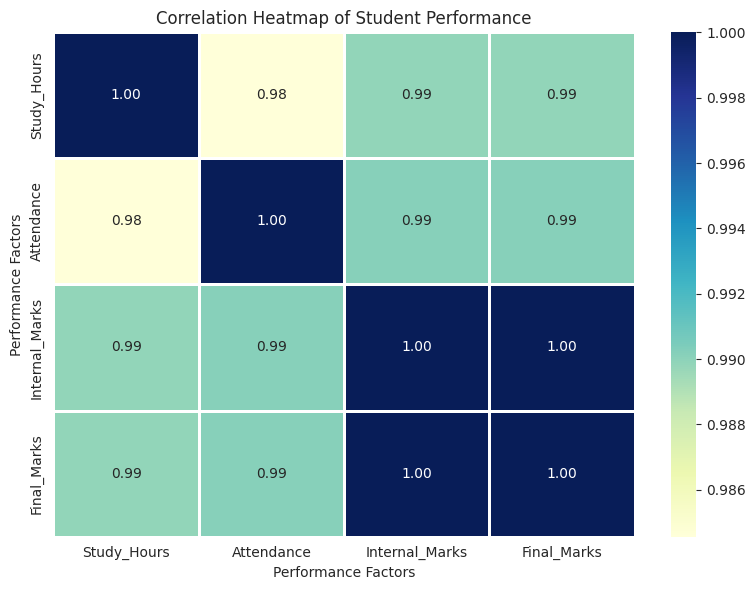

In [4]:
correlation = performance.corr()
print("\n" + "=" * 65)
print("CORRELATION MATRIX")
print("=" * 65)
print(correlation.round(2))
# ---------------------------------------------------------
# 1. CORRELATION HEATMAP
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=1
)
plt.title("Correlation Heatmap of Student Performance")
plt.xlabel("Performance Factors")
plt.ylabel("Performance Factors")
plt.tight_layout()
plt.show()


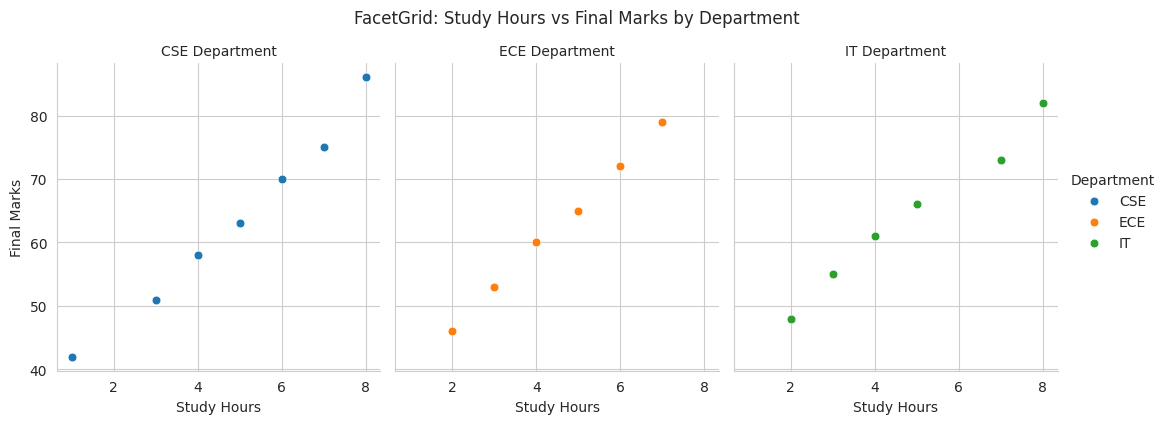

In [5]:
# ---------------------------------------------------------
# 2. FACETGRID
# ---------------------------------------------------------
g = sns.FacetGrid(
    df,
    col="Department",
    hue="Department",
    height=4,
    aspect=0.9
)
g.map_dataframe(
    sns.scatterplot,
    x="Study_Hours",
    y="Final_Marks",
    s=40
)
g.set_axis_labels("Study Hours", "Final Marks")
g.set_titles("{col_name} Department")
g.add_legend()
g.fig.suptitle(
    "FacetGrid: Study Hours vs Final Marks by Department",
    y=1.05
)
plt.show()


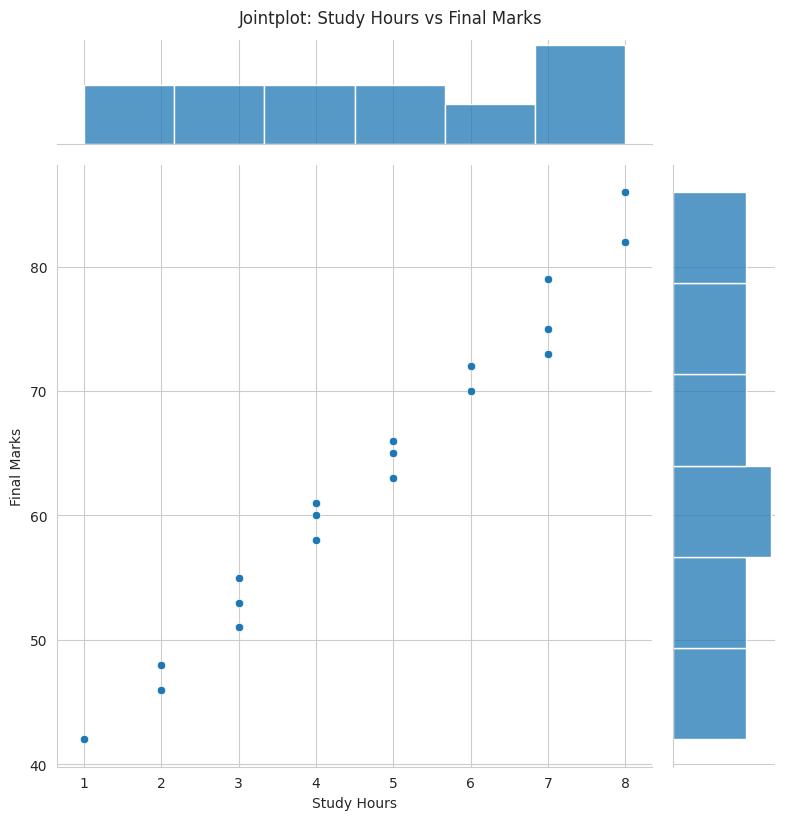

In [6]:
# ---------------------------------------------------------
# 3. JOINTPLOT
# ---------------------------------------------------------
joint = sns.jointplot(
    data=df,
    x="Study_Hours",
    y="Final_Marks",
    kind="scatter",
    height=8
)
joint.fig.suptitle(
    "Jointplot: Study Hours vs Final Marks",
    y=1.02
)
joint.set_axis_labels(
    "Study Hours",
    "Final Marks"
)
plt.show()
